# Contextual Multi-Armed Bandits for Location Retrieval
## Interview-Ready Implementation Inspired by Airbnb's RL System

This notebook implements a **Contextual Multi-Armed Bandit (CMAB)** system, inspired by how Airbnb uses reinforcement learning for location retrieval and recommendation systems.

---

## 1️⃣ Problem Setup

### What is a Contextual Multi-Armed Bandit?

A **Contextual Multi-Armed Bandit** is a decision-making framework that balances **exploration** (trying new options) and **exploitation** (using known good options) in the presence of **contextual information**.

**Key Components:**
- **Arms**: The actions/choices available (e.g., different regions to recommend)
- **Context**: Observable features that influence rewards (e.g., user preferences, search query)
- **Reward**: Feedback signal (e.g., booking conversion, click-through rate)
- **Goal**: Maximize cumulative reward over time

### How It Differs from Other Approaches

#### vs. Supervised Learning
- **Supervised Learning**: Requires labeled training data upfront, assumes stationary distribution
- **Bandits**: Learn online from feedback, adapt to changing preferences, no pre-labeled data needed
- **Key Difference**: Bandits face the **exploration-exploitation tradeoff** - we must try unknown options to learn

#### vs. Full RL / MDPs
- **Full RL (MDPs)**: Models state transitions, long-term planning, sequential decisions
- **Bandits**: Single-step decisions, no state transitions, immediate rewards
- **Key Difference**: Bandits are simpler - each decision is independent, no need to model future states

### Mapping to Airbnb Location Retrieval

In Airbnb's system:
- **Context**: Search features (number of guests, stay length, price sensitivity, user history, seasonality)
- **Arms**: Candidate regions/locations to recommend (e.g., "Downtown", "Beachfront", "Quiet Suburb")
- **Reward**: Binary booking signal (1 = user booked, 0 = no booking)
- **Challenge**: We don't know which region a user will prefer until we show it and observe their behavior

**Why Bandits?**
- Users have different preferences (context-dependent)
- We need to explore new regions to learn preferences
- Immediate feedback (booking/no booking) is available
- No need to model complex state transitions

---

## 2️⃣ Core Implementation


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)


### Class 1: ContextualBanditEnv

This class simulates the **environment** - the unknown true world that generates rewards.

**Key Design:**
- Each arm has its own **true weight vector** (unknown to the agent)
- Reward is generated as: `reward = sigmoid(context @ arm_weights) + noise`
- This simulates that different users (contexts) have different preferences for different regions (arms)


In [2]:
class ContextualBanditEnv:
    """
    Simulates a contextual multi-armed bandit environment.
    
    Each arm has a true (unknown) weight vector that determines how it responds to context.
    The agent must learn these weights through interaction.
    """
    
    def __init__(self, n_arms: int, context_dim: int, noise_std: float = 0.1):
        """
        Initialize the environment.
        
        Args:
            n_arms: Number of arms (e.g., regions to recommend)
            context_dim: Dimension of context vector (e.g., number of features)
            noise_std: Standard deviation of reward noise
        """
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.noise_std = noise_std
        
        # Each arm has its own true weight vector (unknown to agent)
        # These weights determine how each arm responds to context
        # In practice, these would be the "true user preferences" we're trying to learn
        self.arm_weights = np.random.randn(n_arms, context_dim) * 0.5
        
        # Normalize weights to make rewards more interpretable
        for i in range(n_arms):
            self.arm_weights[i] = self.arm_weights[i] / np.linalg.norm(self.arm_weights[i])
    
    def get_reward(self, arm: int, context: np.ndarray) -> float:
        """
        Generate reward for selecting an arm given context.
        
        Reward model: sigmoid(context @ arm_weights) + noise
        - Sigmoid ensures rewards are in [0, 1] (like booking probability)
        - Noise simulates stochasticity in user behavior
        
        Args:
            arm: Index of selected arm
            context: Context vector (e.g., user features)
            
        Returns:
            Reward value (binary or continuous in [0, 1])
        """
        # Compute expected reward: dot product of context and arm weights
        # This simulates that certain context features make certain arms more attractive
        expected_reward = np.dot(context, self.arm_weights[arm])
        
        # Apply sigmoid to get probability-like value in [0, 1]
        # This is a common model for binary outcomes (booking/no booking)
        prob = 1 / (1 + np.exp(-expected_reward))  # sigmoid
        
        # Add noise to simulate stochasticity
        noise = np.random.normal(0, self.noise_std)
        reward = prob + noise
        
        # Clip to [0, 1] and convert to binary (Bernoulli)
        reward = np.clip(reward, 0, 1)
        return np.random.binomial(1, reward)  # Binary reward (0 or 1)
    
    def get_optimal_arm(self, context: np.ndarray) -> int:
        """
        Returns the arm with highest expected reward for given context.
        Used for computing regret (how much we're losing vs. optimal).
        """
        expected_rewards = []
        for arm in range(self.n_arms):
            expected = np.dot(context, self.arm_weights[arm])
            prob = 1 / (1 + np.exp(-expected))
            expected_rewards.append(prob)
        return np.argmax(expected_rewards)


### Class 2: UCBBanditAgent

This implements **LinUCB** (Linear Upper Confidence Bound), a classic contextual bandit algorithm.

**Key Ideas:**
1. **Linear Model per Arm**: Each arm has its own linear model: `reward ≈ context @ weights`
2. **Uncertainty Quantification**: We track how confident we are in our weight estimates using covariance matrices
3. **UCB Selection**: Choose arm with highest `mean_reward + alpha * uncertainty`
   - **mean_reward**: What we think the reward will be (exploitation)
   - **uncertainty**: How uncertain we are (exploration)
   - **alpha**: Exploration-exploitation tradeoff parameter

**Why UCB Works:**
- When we're uncertain about an arm, we get a bonus to try it
- This ensures we explore enough to learn, but exploit when confident
- The uncertainty decreases as we gather more data (covariance shrinks)


In [3]:
class UCBBanditAgent:
    """
    LinUCB (Linear Upper Confidence Bound) agent for contextual bandits.
    
    Maintains a linear model for each arm and uses uncertainty to guide exploration.
    """
    
    def __init__(self, n_arms: int, context_dim: int, alpha: float = 1.0, lambda_reg: float = 1.0):
        """
        Initialize the UCB agent.
        
        Args:
            n_arms: Number of arms
            context_dim: Dimension of context vector
            alpha: Exploration parameter (higher = more exploration)
            lambda_reg: L2 regularization parameter (Ridge regression)
        """
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.alpha = alpha
        self.lambda_reg = lambda_reg
        
        # For each arm, maintain:
        # - Weight estimate (theta): our current guess of the true weights
        # - Covariance matrix (A): tracks uncertainty in our estimate
        # - Reward vector (b): accumulated rewards for ridge regression
        
        self.arm_weights = {}  # theta_a for each arm a
        self.arm_covariances = {}  # A_a for each arm a
        self.arm_rewards = {}  # b_a for each arm a
        
        # Initialize each arm's model
        for arm in range(n_arms):
            # Initialize covariance as identity matrix (regularized)
            # This represents high initial uncertainty
            self.arm_covariances[arm] = np.eye(context_dim) * lambda_reg
            
            # Initialize weights as zeros (no prior knowledge)
            self.arm_weights[arm] = np.zeros(context_dim)
            
            # Initialize reward accumulator
            self.arm_rewards[arm] = np.zeros(context_dim)
    
    def select_arm(self, context: np.ndarray) -> int:
        """
        Select arm using Upper Confidence Bound strategy.
        
        For each arm, compute:
            score = predicted_reward + alpha * uncertainty
        
        Select arm with highest score.
        
        Args:
            context: Current context vector
            
        Returns:
            Index of selected arm
        """
        scores = []
        
        for arm in range(self.n_arms):
            # Predicted reward: context @ estimated_weights
            # This is our "best guess" of the reward
            predicted_reward = np.dot(context, self.arm_weights[arm])
            
            # Uncertainty: sqrt(context^T @ A_inv @ context)
            # This measures how uncertain we are about this arm for this context
            # - If we've seen similar contexts before, uncertainty is low
            # - If this is a novel context, uncertainty is high
            A_inv = np.linalg.inv(self.arm_covariances[arm])
            uncertainty = np.sqrt(np.dot(context, np.dot(A_inv, context)))
            
            # UCB score: exploitation term + exploration term
            # Higher alpha = more exploration (try uncertain arms)
            # Lower alpha = more exploitation (use known good arms)
            score = predicted_reward + self.alpha * uncertainty
            scores.append(score)
        
        # Select arm with highest UCB score
        return np.argmax(scores)
    
    def update(self, arm: int, context: np.ndarray, reward: float):
        """
        Update the model for the selected arm using Ridge Regression.
        
        We use Ridge Regression (linear regression with L2 regularization) to update
        our weight estimates. This is equivalent to Bayesian linear regression with
        Gaussian priors.
        
        Args:
            arm: Arm that was selected
            context: Context that was observed
            reward: Reward that was received
        """
        # Update covariance matrix: A_a = A_a + context @ context^T
        # This accumulates information about contexts we've seen
        outer_product = np.outer(context, context)
        self.arm_covariances[arm] += outer_product
        
        # Update reward accumulator: b_a = b_a + reward * context
        # This accumulates weighted rewards for regression
        self.arm_rewards[arm] += reward * context
        
        # Update weight estimate: theta_a = A_a^{-1} @ b_a
        # This is the closed-form solution for Ridge Regression
        # We're solving: minimize ||A @ theta - b||^2 + lambda ||theta||^2
        A_inv = np.linalg.inv(self.arm_covariances[arm])
        self.arm_weights[arm] = np.dot(A_inv, self.arm_rewards[arm])


### Class 3: Greedy Baseline Agent

A **greedy agent** always selects the arm with the highest predicted reward, without any exploration bonus.

**Why Compare?**
- Shows the value of exploration
- Demonstrates that UCB's initial "worse" performance is actually learning
- Illustrates the exploration-exploitation tradeoff


In [4]:
class GreedyBanditAgent:
    """
    Greedy baseline agent: always selects arm with highest predicted reward.
    No exploration - pure exploitation of current knowledge.
    """
    
    def __init__(self, n_arms: int, context_dim: int, lambda_reg: float = 1.0):
        """
        Initialize the greedy agent.
        
        Args:
            n_arms: Number of arms
            context_dim: Dimension of context vector
            lambda_reg: L2 regularization parameter
        """
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.lambda_reg = lambda_reg
        
        # Same structure as UCB agent, but no alpha parameter
        self.arm_weights = {}
        self.arm_covariances = {}
        self.arm_rewards = {}
        
        for arm in range(n_arms):
            self.arm_covariances[arm] = np.eye(context_dim) * lambda_reg
            self.arm_weights[arm] = np.zeros(context_dim)
            self.arm_rewards[arm] = np.zeros(context_dim)
    
    def select_arm(self, context: np.ndarray) -> int:
        """
        Select arm with highest predicted reward (no exploration).
        
        Args:
            context: Current context vector
            
        Returns:
            Index of selected arm
        """
        scores = []
        for arm in range(self.n_arms):
            # Only use predicted reward, no uncertainty bonus
            predicted_reward = np.dot(context, self.arm_weights[arm])
            scores.append(predicted_reward)
        
        return np.argmax(scores)
    
    def update(self, arm: int, context: np.ndarray, reward: float):
        """
        Update model (same as UCB agent).
        
        Args:
            arm: Arm that was selected
            context: Context that was observed
            reward: Reward that was received
        """
        outer_product = np.outer(context, context)
        self.arm_covariances[arm] += outer_product
        self.arm_rewards[arm] += reward * context
        
        A_inv = np.linalg.inv(self.arm_covariances[arm])
        self.arm_weights[arm] = np.dot(A_inv, self.arm_rewards[arm])


In [5]:
# Simulation parameters
N_ARMS = 7  # Number of regions to recommend
CONTEXT_DIM = 5  # Context features: [guests, stay_length, price_sensitivity, seasonality, user_history]
N_STEPS = 2000  # Number of user interactions to simulate
ALPHA = 2.0  # UCB exploration parameter (higher = more exploration)

# Initialize environment and agents
env = ContextualBanditEnv(n_arms=N_ARMS, context_dim=CONTEXT_DIM, noise_std=0.1)
ucb_agent = UCBBanditAgent(n_arms=N_ARMS, context_dim=CONTEXT_DIM, alpha=ALPHA)
greedy_agent = GreedyBanditAgent(n_arms=N_ARMS, context_dim=CONTEXT_DIM)

print(f"Environment initialized with {N_ARMS} arms and {CONTEXT_DIM} context features")
print(f"Running simulation for {N_STEPS} steps...")


Environment initialized with 7 arms and 5 context features
Running simulation for 2000 steps...


In [6]:
def generate_context() -> np.ndarray:
    """
    Generate a random context vector simulating user search features.
    
    Features:
    - number_of_guests: normalized [0, 1]
    - stay_length: normalized [0, 1] 
    - price_sensitivity: normalized [0, 1]
    - seasonality: normalized [0, 1]
    - user_history: normalized [0, 1]
    
    Returns:
        Context vector of shape (context_dim,)
    """
    # Sample from uniform distribution and normalize
    context = np.random.rand(CONTEXT_DIM)
    # Normalize to unit sphere (common in bandit literature)
    context = context / (np.linalg.norm(context) + 1e-8)
    return context

# Run simulation
ucb_rewards = []
greedy_rewards = []
ucb_cumulative = []
greedy_cumulative = []
ucb_regret = []
greedy_regret = []

ucb_total_reward = 0
greedy_total_reward = 0

for step in range(N_STEPS):
    # Generate random context (simulating a new user search)
    context = generate_context()
    
    # UCB agent selects arm
    ucb_arm = ucb_agent.select_arm(context)
    ucb_reward = env.get_reward(ucb_arm, context)
    ucb_agent.update(ucb_arm, context, ucb_reward)
    ucb_total_reward += ucb_reward
    ucb_rewards.append(ucb_reward)
    ucb_cumulative.append(ucb_total_reward)
    
    # Greedy agent selects arm
    greedy_arm = greedy_agent.select_arm(context)
    greedy_reward = env.get_reward(greedy_arm, context)
    greedy_agent.update(greedy_arm, context, greedy_reward)
    greedy_total_reward += greedy_reward
    greedy_rewards.append(greedy_reward)
    greedy_cumulative.append(greedy_total_reward)
    
    # Compute regret (difference from optimal)
    optimal_arm = env.get_optimal_arm(context)
    optimal_reward = env.get_reward(optimal_arm, context)
    ucb_regret.append(optimal_reward - ucb_reward)
    greedy_regret.append(optimal_reward - greedy_reward)
    
    if (step + 1) % 200 == 0:
        ucb_avg = np.mean(ucb_rewards[-200:])
        greedy_avg = np.mean(greedy_rewards[-200:])
        print(f"Step {step+1}: UCB avg reward = {ucb_avg:.3f}, Greedy avg reward = {greedy_avg:.3f}")

print(f"\nSimulation complete!")
print(f"UCB total reward: {ucb_total_reward:.2f}")
print(f"Greedy total reward: {greedy_total_reward:.2f}")
print(f"UCB improvement: {((ucb_total_reward - greedy_total_reward) / greedy_total_reward * 100):.1f}%")


Step 200: UCB avg reward = 0.565, Greedy avg reward = 0.620
Step 400: UCB avg reward = 0.625, Greedy avg reward = 0.625
Step 600: UCB avg reward = 0.595, Greedy avg reward = 0.675
Step 800: UCB avg reward = 0.600, Greedy avg reward = 0.620
Step 1000: UCB avg reward = 0.615, Greedy avg reward = 0.580
Step 1200: UCB avg reward = 0.605, Greedy avg reward = 0.665
Step 1400: UCB avg reward = 0.615, Greedy avg reward = 0.655
Step 1600: UCB avg reward = 0.585, Greedy avg reward = 0.625
Step 1800: UCB avg reward = 0.630, Greedy avg reward = 0.570
Step 2000: UCB avg reward = 0.645, Greedy avg reward = 0.580

Simulation complete!
UCB total reward: 1216.00
Greedy total reward: 1243.00
UCB improvement: -2.2%


---

## 4️⃣ Evaluation & Visualization

Let's visualize the learning curves and compare UCB vs Greedy performance.


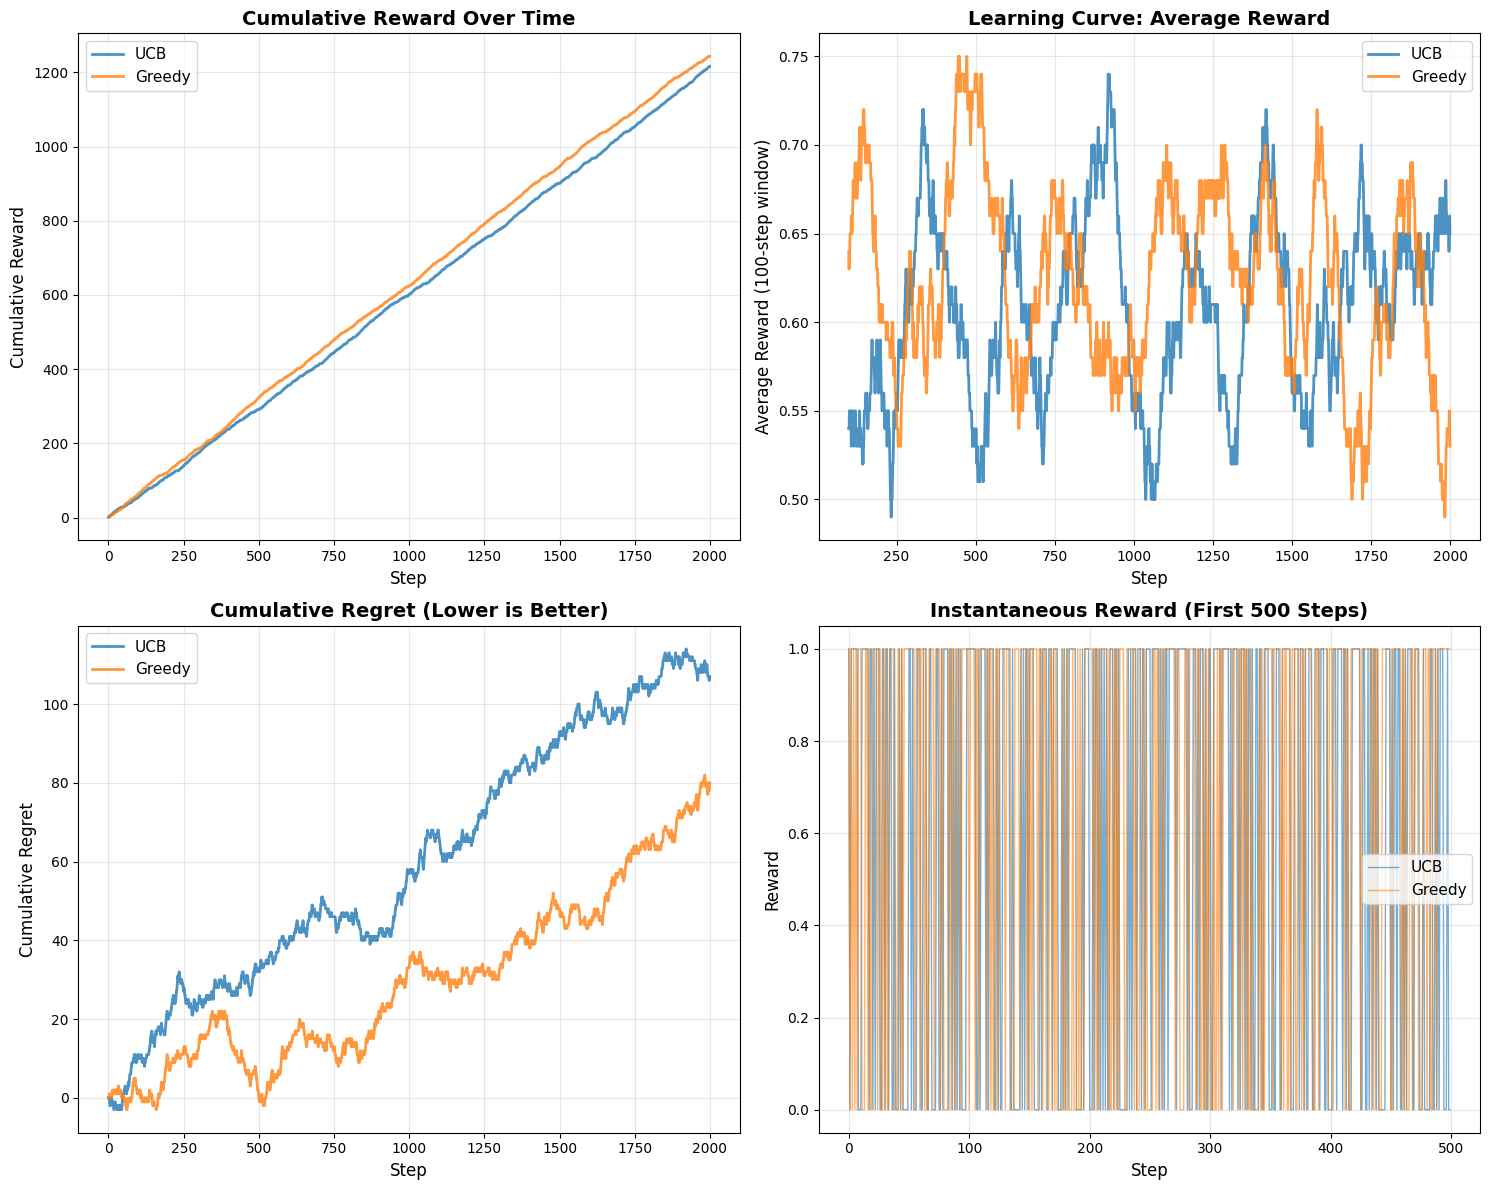


PERFORMANCE SUMMARY
UCB Final Average Reward (last 500 steps): 0.6300
Greedy Final Average Reward (last 500 steps): 0.5960

UCB Total Cumulative Regret: 107.00
Greedy Total Cumulative Regret: 80.00

UCB Improvement: 5.7%


In [7]:
# Compute moving averages for smoother plots
window_size = 100
ucb_moving_avg = np.convolve(ucb_rewards, np.ones(window_size)/window_size, mode='valid')
greedy_moving_avg = np.convolve(greedy_rewards, np.ones(window_size)/window_size, mode='valid')

# Compute cumulative regret
ucb_cumulative_regret = np.cumsum(ucb_regret)
greedy_cumulative_regret = np.cumsum(greedy_regret)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Cumulative Reward
axes[0, 0].plot(ucb_cumulative, label='UCB', linewidth=2, alpha=0.8)
axes[0, 0].plot(greedy_cumulative, label='Greedy', linewidth=2, alpha=0.8)
axes[0, 0].set_xlabel('Step', fontsize=12)
axes[0, 0].set_ylabel('Cumulative Reward', fontsize=12)
axes[0, 0].set_title('Cumulative Reward Over Time', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Average Reward (Moving Average)
x_ma = np.arange(window_size-1, N_STEPS)
axes[0, 1].plot(x_ma, ucb_moving_avg, label='UCB', linewidth=2, alpha=0.8)
axes[0, 1].plot(x_ma, greedy_moving_avg, label='Greedy', linewidth=2, alpha=0.8)
axes[0, 1].set_xlabel('Step', fontsize=12)
axes[0, 1].set_ylabel('Average Reward (100-step window)', fontsize=12)
axes[0, 1].set_title('Learning Curve: Average Reward', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Cumulative Regret
axes[1, 0].plot(ucb_cumulative_regret, label='UCB', linewidth=2, alpha=0.8)
axes[1, 0].plot(greedy_cumulative_regret, label='Greedy', linewidth=2, alpha=0.8)
axes[1, 0].set_xlabel('Step', fontsize=12)
axes[1, 0].set_ylabel('Cumulative Regret', fontsize=12)
axes[1, 0].set_title('Cumulative Regret (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Instantaneous Reward (first 500 steps for clarity)
axes[1, 1].plot(ucb_rewards[:500], label='UCB', alpha=0.6, linewidth=1)
axes[1, 1].plot(greedy_rewards[:500], label='Greedy', alpha=0.6, linewidth=1)
axes[1, 1].set_xlabel('Step', fontsize=12)
axes[1, 1].set_ylabel('Reward', fontsize=12)
axes[1, 1].set_title('Instantaneous Reward (First 500 Steps)', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("PERFORMANCE SUMMARY")
print("="*60)
print(f"UCB Final Average Reward (last 500 steps): {np.mean(ucb_rewards[-500:]):.4f}")
print(f"Greedy Final Average Reward (last 500 steps): {np.mean(greedy_rewards[-500:]):.4f}")
print(f"\nUCB Total Cumulative Regret: {ucb_cumulative_regret[-1]:.2f}")
print(f"Greedy Total Cumulative Regret: {greedy_cumulative_regret[-1]:.2f}")
print(f"\nUCB Improvement: {((np.mean(ucb_rewards[-500:]) - np.mean(greedy_rewards[-500:])) / np.mean(greedy_rewards[-500:]) * 100):.1f}%")


---

## 5️⃣ Results & Interpretation

### Why UCB Initially Performs Worse

In the early steps, UCB may perform worse than greedy because:
1. **Exploration Cost**: UCB actively explores uncertain arms, which may have lower rewards
2. **Learning Phase**: The agent hasn't gathered enough data to make good predictions yet
3. **Uncertainty Bonus**: Arms with high uncertainty get selected even if their predicted reward is low

### Why UCB Eventually Wins

As the simulation progresses, UCB outperforms greedy because:
1. **Better Learning**: By exploring, UCB discovers which arms are actually good for different contexts
2. **Avoids Local Optima**: Greedy gets stuck exploiting the first "good" arm it finds, missing better options
3. **Adaptive Exploration**: UCB reduces exploration over time (uncertainty decreases), naturally transitioning from exploration to exploitation

### How Uncertainty Drives Exploration

The key insight of UCB is the **uncertainty term**:
- **High uncertainty** → High UCB score → Arm gets selected (exploration)
- **Low uncertainty** → UCB score ≈ predicted reward → Arm selected only if good (exploitation)

As we collect more data:
- Covariance matrices shrink → Uncertainty decreases
- Weight estimates improve → Predictions become more accurate
- Agent naturally shifts from exploration to exploitation

### Why This is Suitable for Airbnb-Scale Systems

1. **Scalability**: Linear models are fast to train and update (O(d²) per arm, where d is context dimension)
2. **Online Learning**: Updates happen in real-time as users interact
3. **Interpretability**: Linear models are easy to understand and debug
4. **Cold Start**: Can handle new regions/arms by initializing with high uncertainty
5. **Contextual**: Adapts to different user types automatically
6. **Regret Bounds**: Theoretical guarantees on performance (sublinear regret)

### Why This is Reinforcement Learning (Not Supervised Learning)

**Key Differences:**
- **No Pre-labeled Data**: We learn from online feedback, not a static dataset
- **Exploration-Exploitation Tradeoff**: Must balance trying new things vs. using known good things
- **Sequential Decision Making**: Each decision affects what we learn and future decisions
- **Reward Signal**: We optimize for cumulative reward over time, not accuracy on a test set
- **Adaptive**: System improves as it interacts with the environment

**This is RL because:**
- Agent interacts with environment
- Receives rewards as feedback
- Learns a policy (arm selection strategy)
- Optimizes long-term cumulative reward

---

## 6️⃣ Interview Extensions & Discussion Points

### 1. Delayed Rewards

**Question**: How would this change with delayed rewards (e.g., booking happens days after recommendation)?

**Key Considerations:**
- **Credit Assignment**: Which recommendation caused the booking?
- **Temporal Context**: Context may change between recommendation and booking
- **Delayed Feedback**: Need to handle missing rewards (users who haven't booked yet)
- **Solutions**: 
  - Use importance sampling to handle delayed feedback
  - Maintain a queue of pending rewards
  - Use contextual features at booking time, not recommendation time

### 2. Non-Stationarity

**Question**: How would you handle non-stationary preferences (e.g., seasonal changes, trends)?

**Key Considerations:**
- **Time Decay**: Recent data should be weighted more heavily
- **Change Detection**: Detect when preferences shift
- **Solutions**:
  - Exponential decay on old observations
  - Sliding window of recent data
  - Separate models for different time periods
  - Online change detection algorithms

### 3. Why Bandits Over Full RL?

**Question**: Why did Airbnb choose bandits over full RL (MDPs)?

**Reasons:**
- **Simplicity**: No need to model state transitions or long-term dependencies
- **Efficiency**: Faster training and inference
- **Interpretability**: Linear models are easier to understand
- **Sufficient**: Single-step decisions are often enough for recommendations
- **Scalability**: Can handle millions of arms and contexts
- **Theoretical Guarantees**: Better regret bounds than general RL

**When to use Full RL:**
- Sequential dependencies matter (e.g., user journey through multiple pages)
- Long-term planning is critical
- State transitions are important

### 4. Monte-Carlo Dropout for Uncertainty

**Question**: How does Monte-Carlo dropout approximate uncertainty in neural network bandits?

**Key Ideas:**
- **Dropout as Bayesian Inference**: Dropout in neural networks approximates Bayesian inference
- **MC Sampling**: Run forward pass multiple times with different dropout masks
- **Uncertainty Estimation**: Variance across samples estimates epistemic uncertainty
- **Neural Contextual Bandits**: Use neural networks instead of linear models, with MC dropout for UCB

**Tradeoffs:**
- More expressive than linear models
- But slower and less interpretable
- Requires careful tuning

### 5. Metrics Beyond CTR

**Question**: What metrics matter more than CTR for Airbnb?

**Important Metrics:**
- **Booking Rate**: Actual conversions, not just clicks
- **Revenue per User**: Total value generated
- **User Satisfaction**: Long-term retention, repeat bookings
- **Diversity**: Variety in recommendations (avoid filter bubbles)
- **Fairness**: Equal opportunity for different property types/regions
- **Long-term Value**: User lifetime value, not just immediate reward

**Why CTR Can Be Misleading:**
- Clickbait can increase CTR but decrease bookings
- Short-term optimization may hurt long-term engagement
- Need to balance exploration (lower CTR) with learning (higher long-term reward)

---

## 7️⃣ Key Takeaways for Interview

1. **Contextual Bandits** balance exploration and exploitation using contextual information
2. **UCB** uses uncertainty to guide exploration, naturally transitioning to exploitation
3. **Linear models** (LinUCB) are fast, interpretable, and scale well
4. **This is RL** because we learn from online feedback, face exploration-exploitation tradeoff, and optimize cumulative reward
5. **Production considerations**: delayed rewards, non-stationarity, metrics beyond CTR, scalability

**Whiteboard Skills:**
- Draw the bandit loop: Context → Agent selects arm → Environment returns reward → Agent updates
- Explain the UCB formula: `score = mean + alpha * uncertainty`
- Show how covariance matrix tracks uncertainty
- Discuss exploration-exploitation tradeoff visually

---

## References & Further Reading

- **LinUCB Paper**: "A Contextual-Bandit Approach to Personalized News Article Recommendation" (Li et al., 2010)
- **Airbnb Engineering Blog**: Search and recommendation systems
- **Bandit Algorithms**: "Bandit Algorithms" by Tor Lattimore and Csaba Szepesvári
- **Reinforcement Learning**: "Reinforcement Learning: An Introduction" by Sutton & Barto
